In [10]:
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import numpy as np

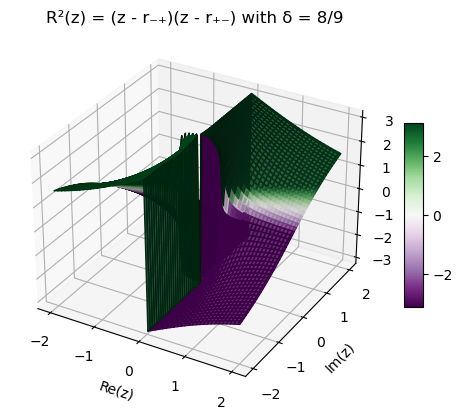

In [12]:
X, Y = np.meshgrid(np.linspace(-2,2,100), np.linspace(-2,2,100))
Z = X + 1j*Y

delta = 8/9

def A(x):
	return np.sqrt(1-delta**2*(1/np.cosh(x))**2)

r_minus_max = -A(0)
r_plus_min = A(0)


def plot3D(func, X, Y, Z, title: str):
	plt.close('all')
	fig = plt.figure()
	ax = fig.add_subplot(111, projection='3d')
	# surf = ax.plot_surface(X, Y, np.abs(func(Z)), facecolors=cm.PRGn(np.angle(func(Z))), cmap='PRGn', alpha=0.8, antialiased=True)
	surf = ax.plot_surface(X, Y, np.angle(func(Z)), facecolors=cm.PRGn(np.angle(func(Z))), alpha=0.8, antialiased=True)
	ax.set_xlabel('Re(z)')
	ax.set_ylabel('Im(z)')
	ax.set_zlabel('R²(z)')
	plt.title(title)
	mappable = cm.ScalarMappable(norm=colors.Normalize(vmin=-np.pi, vmax=np.pi), cmap=cm.PRGn)
	fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=10)
	plt.show()

def R_squared(z):
	return (z-r_minus_max)*(z-r_plus_min)

plot3D(R_squared, X, Y, Z, 'R²(z) = (z - r₋₊)(z - r₊₋) with δ = 8/9',)


def mysqrt(z):
	if np.imag(z) >=0:
		return np.sqrt(z)
	else:
		return -np.sqrt(z)


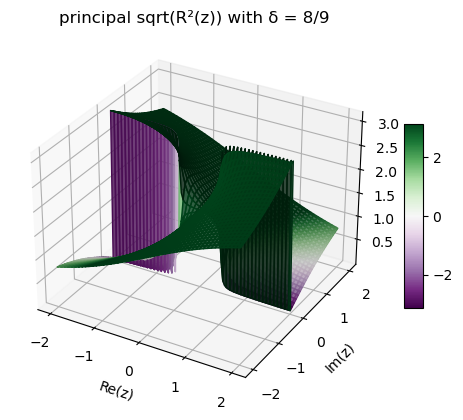

In [13]:

vmysqrt=np.vectorize(mysqrt)


# plot3D(np.sqrt, X, Y, R_squared(Z), 'principal sqrt(R²(z)) with δ = 8/9')
plot3D(vmysqrt, X, Y, R_squared(Z), 'principal sqrt(R²(z)) with δ = 8/9')